In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import seaborn as sns 
import math
import random
from scipy.integrate import simps
from sklearn.manifold import TSNE
from scipy.integrate import simps
from scipy import stats
from datetime import datetime
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from statannotations.Annotator import Annotator
import scipy.signal
from scipy.stats import exponnorm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from lmfit.models import GaussianModel
from lmfit.models import GaussianModel,ExponentialGaussianModel,SkewedGaussianModel,VoigtModel,LorentzianModel,LognormalModel
from scipy.signal import savgol_filter, find_peaks, find_peaks_cwt
from scipy import sparse
from scipy.sparse.linalg import spsolve
import scipy
import pybaselines


plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["font.family"] = "Arial"
sns.set(font_scale=2.5)
sns.set_style("ticks")
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
def make_entry(filename, sample_name,replicate,mass=1): 
    """
    Inputs: HPLC trace (csv), lipid class (string), genetic background (string),multiplier (to make visible int)
    and topfluor (an int representing the amount of topfluor in the sample that is used as a normalization control)
    Outputs: An array of dictionaries for each moment in the hplc trace 
    """
    csv=pd.read_csv(filename,skiprows=range(0, 42),sep="\t")
    hplc=[]
    area=100
    """
    for row in csv.itertuples():
        if row[1]>5 and row[1]<80:
            area+=row[3]
    """
    print(area/100)
    area=area/100
    #iterates through the rows of the CSV and adds a dictionary entry for that time point 
    for row in csv.itertuples():
        #iterates through the rows of the CSV and adds a dictionary entry for that time point 
        if isinstance(row[3],str):
            hplc.append({"Time":row[1],"Value":float(row[3].replace(',','')), "Genotype":sample_name,"Replicate":replicate})
        else: 
            hplc.append({"Time":row[1],"Value":row[3]/mass, "Genotype":sample_name,"Replicate":replicate})
    return hplc

In [4]:
livers=[]
livers+=make_entry("AB liver 6_03_Emission_1.txt","WT",1)
livers+=make_entry("asgr liver 1_04_Emission_1.txt","$asgr1a^{c830/c830}$",1)
liver=pd.DataFrame(livers)
liver

1.0
1.0


,Time,Value,Genotype,Replicate
0,0.003283,-381.0,WT,1
1,0.006617,-381.0,WT,1
2,0.009950,-381.0,WT,1
3,0.013283,-381.0,WT,1
4,0.016617,-381.0,WT,1
...,...,...,...,...
64497,107.490017,-119619.0,$asgr1a^{c830/c830}$,1
64498,107.493350,-119409.0,$asgr1a^{c830/c830}$,1
64499,107.496683,-119249.0,$asgr1a^{c830/c830}$,1
64500,107.500017,-119131.0,$asgr1a^{c830/c830}$,1


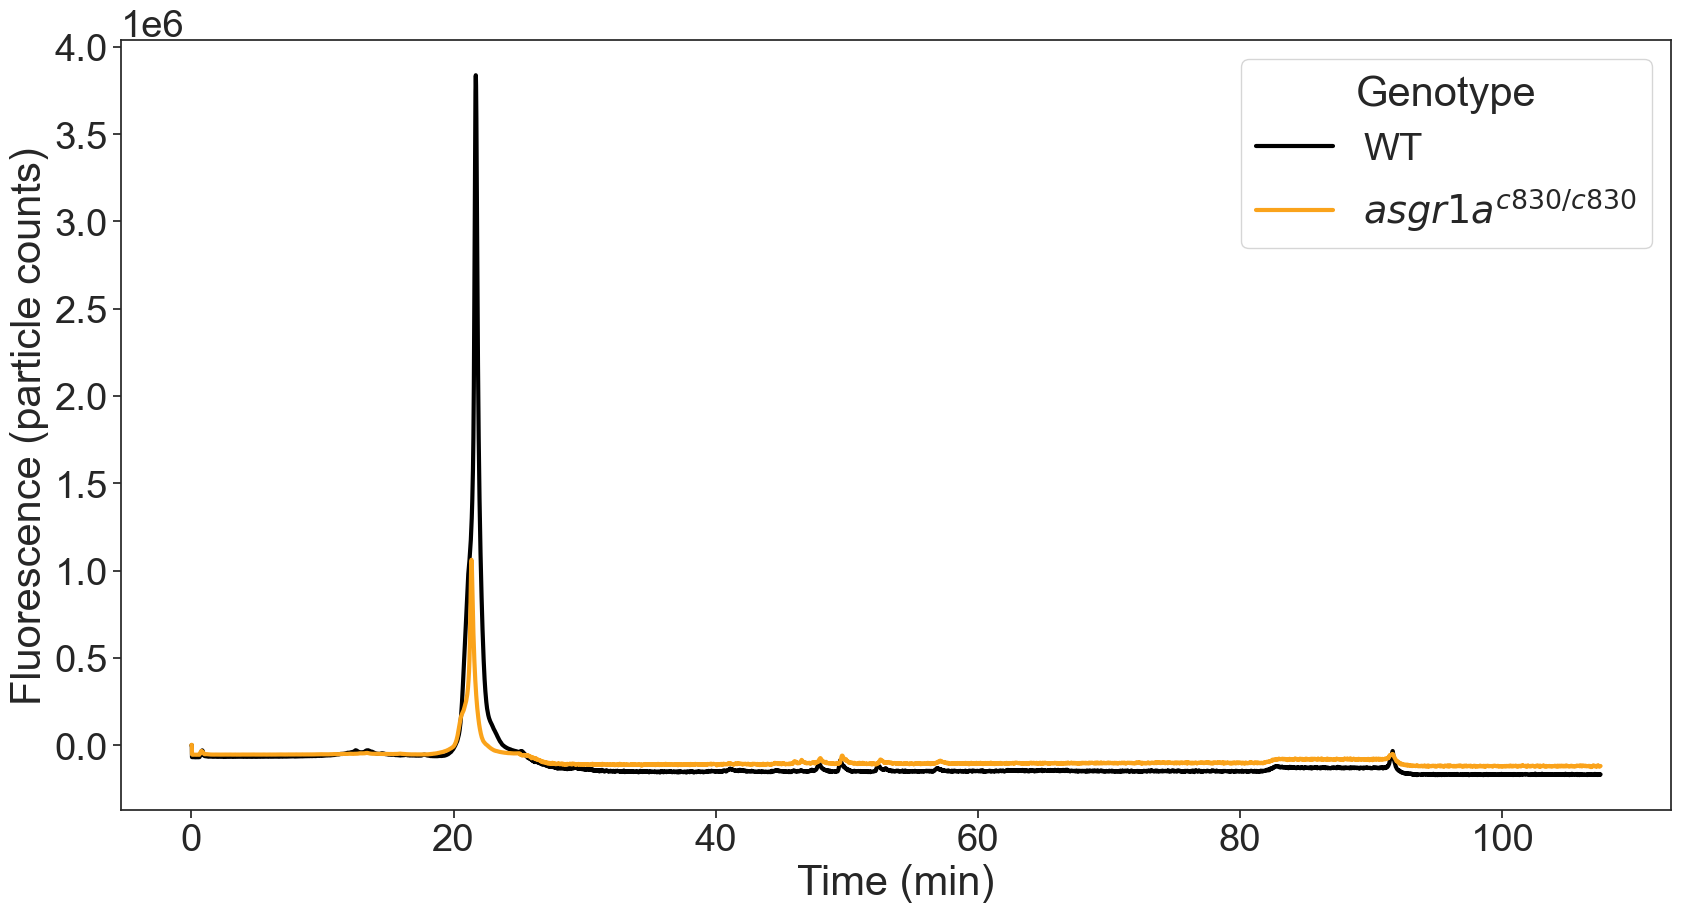

In [5]:
fig,ax=plt.subplots(figsize=(20,10))
sns.lineplot(data=liver,x="Time",y="Value",hue="Genotype",palette=["Black","#FAA31B"],linewidth=3)
ax.set_ylabel("Fluorescence (particle counts)")
ax.set_xlabel("Time (min)")
#plt.savefig("6a.svg")
plt.show()

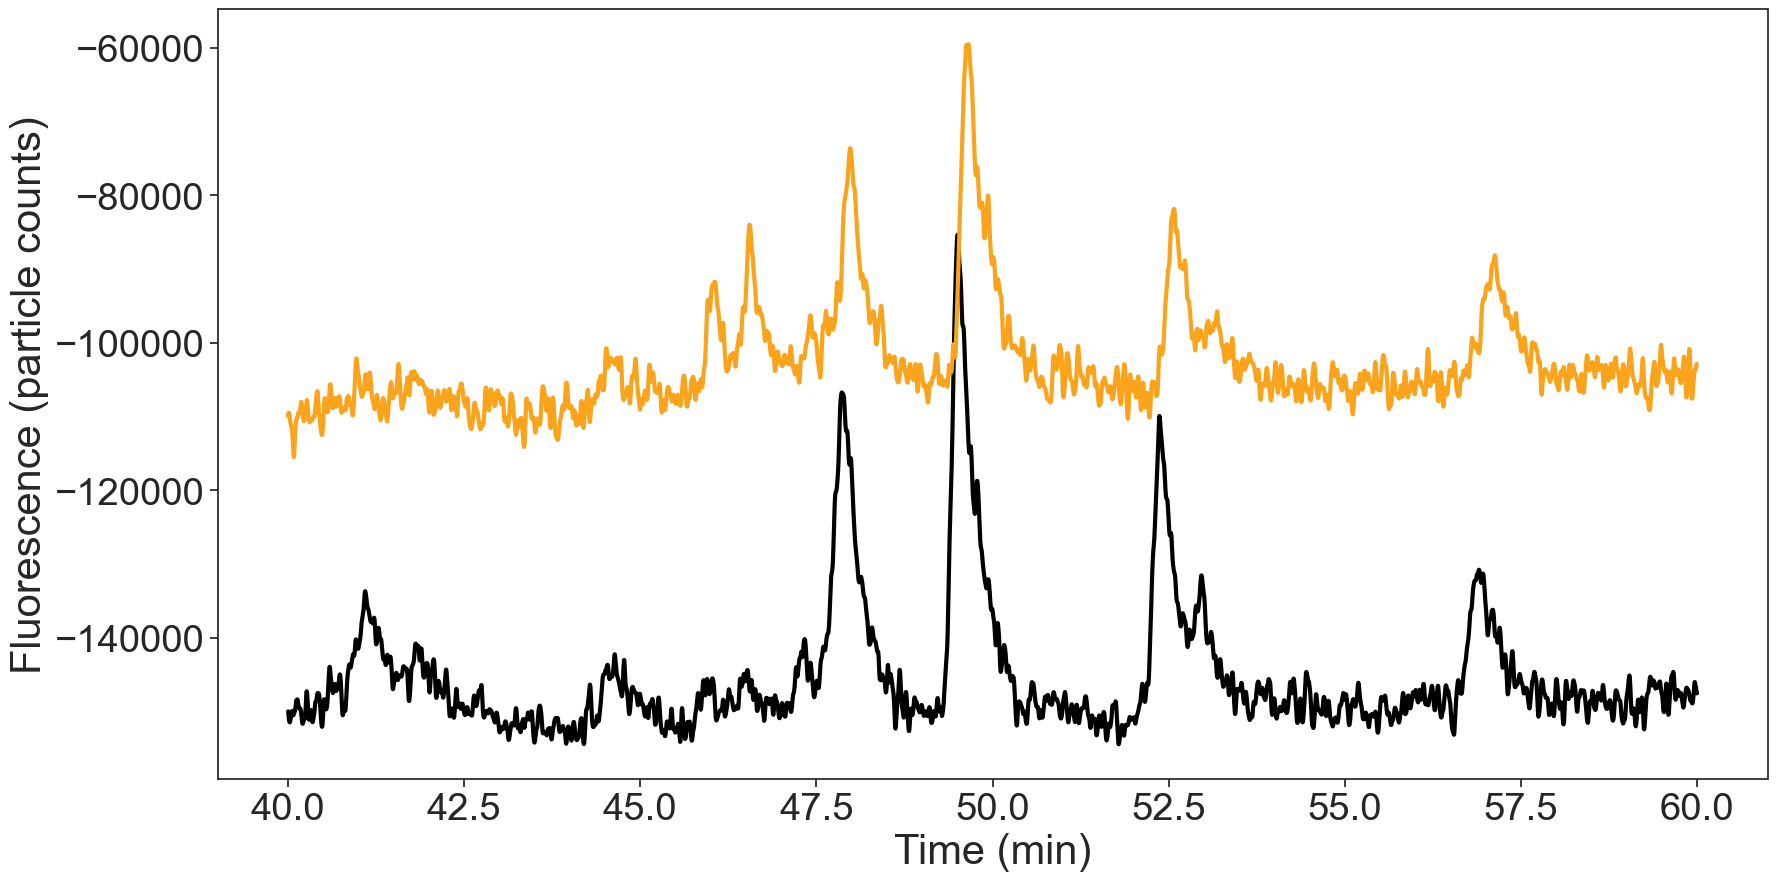

In [6]:
fig,ax=plt.subplots(figsize=(20,10))
sns.lineplot(data=liver[(liver.Time>40)&(liver.Time<60)],x="Time",y="Value",hue="Genotype",palette=["Black","#FAA31B"],linewidth=3,legend=False)
ax.set_ylabel("Fluorescence (particle counts)")
ax.set_xlabel("Time (min)")
#plt.savefig("6a_inset.svg")
plt.show()

In [8]:
intestines=[]
intestines+=make_entry("AB int 2_08_Emission_1.txt","WT",1)
intestines+=make_entry("Asgr int 3_07_Emission_1.txt","asgr1a",1)
intestine=pd.DataFrame(intestines)
intestine

1.0
1.0


,Time,Value,Genotype,Replicate
0,0.003400,3429.0,WT,1
1,0.006733,3429.0,WT,1
2,0.010067,3429.0,WT,1
3,0.013400,3429.0,WT,1
4,0.016733,3429.0,WT,1
...,...,...,...,...
64497,107.490033,-250949.0,asgr1a,1
64498,107.493367,-251080.0,asgr1a,1
64499,107.496700,-251191.0,asgr1a,1
64500,107.500033,-251266.0,asgr1a,1


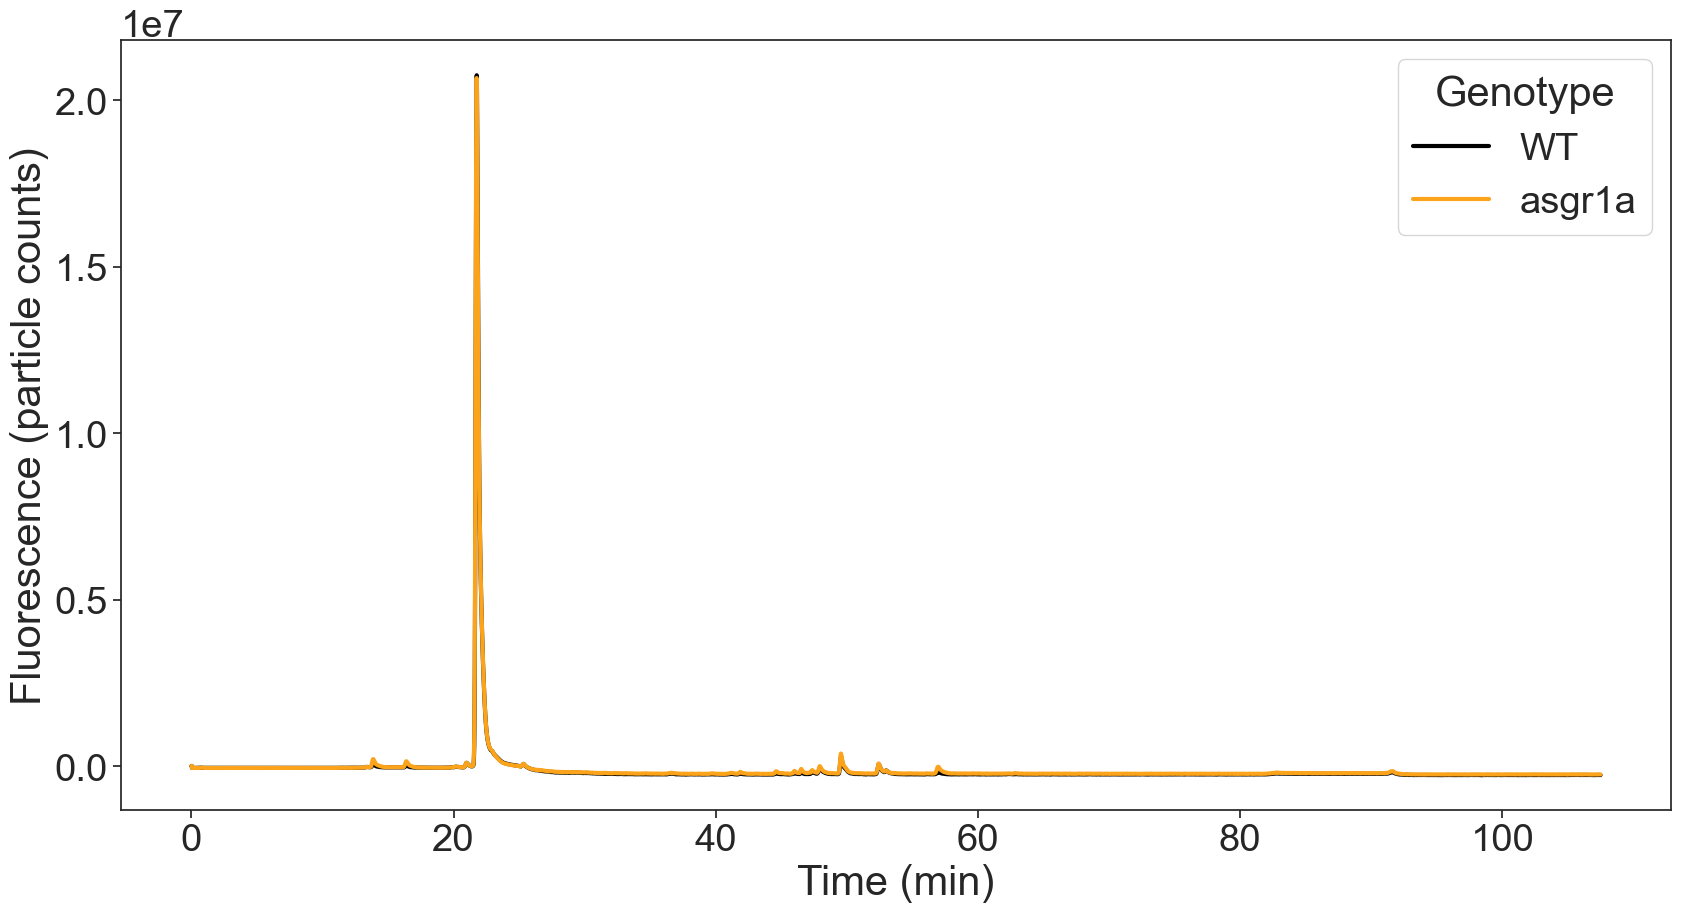

In [9]:
fig,ax=plt.subplots(figsize=(20,10))
sns.lineplot(data=intestine,x="Time",y="Value",hue="Genotype",palette=["Black","#FAA31B"],linewidth=3)
ax.set_ylabel("Fluorescence (particle counts)")
ax.set_xlabel("Time (min)")
#plt.savefig("6c.svg")
plt.show()

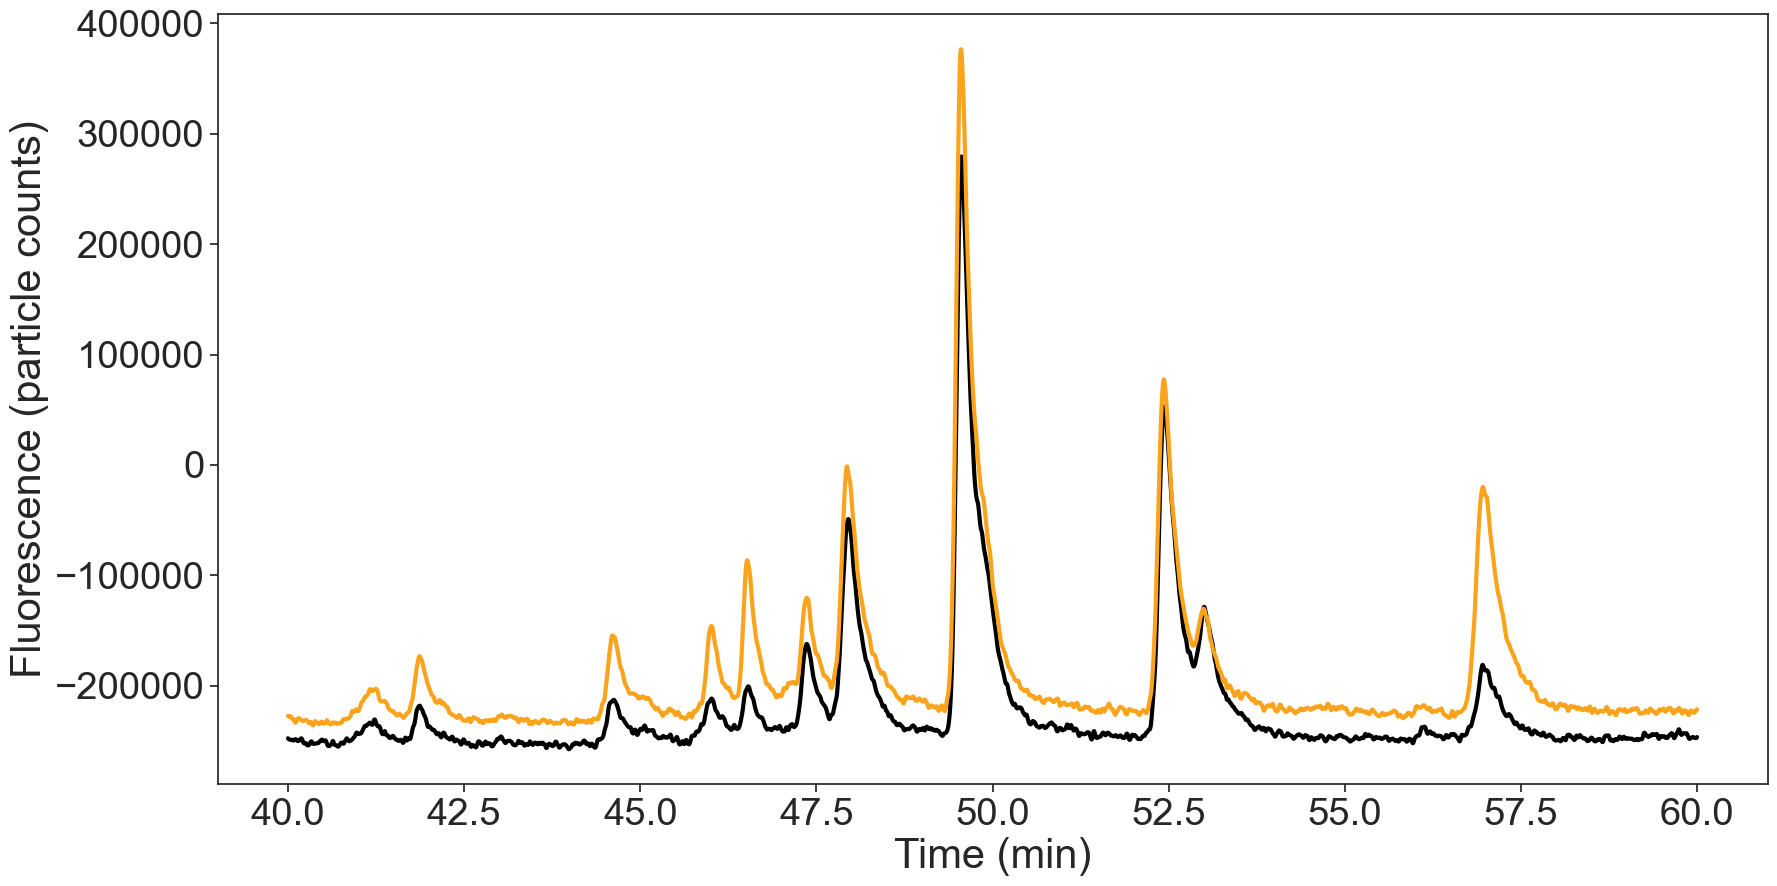

In [10]:
fig,ax=plt.subplots(figsize=(20,10))
sns.lineplot(data=intestine[(intestine.Time>40)&(intestine.Time<60)],x="Time",y="Value",hue="Genotype",palette=["Black","#FAA31B"],linewidth=3,legend=False)
ax.set_ylabel("Fluorescence (particle counts)")
ax.set_xlabel("Time (min)")
#plt.savefig("6c_inset.svg")
plt.show()

In [12]:
fig7B=pd.read_excel("secretion_peak_climber.xlsx")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AB vs. $asgr1a^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:6.905e-01 U_stat=1.500e+01


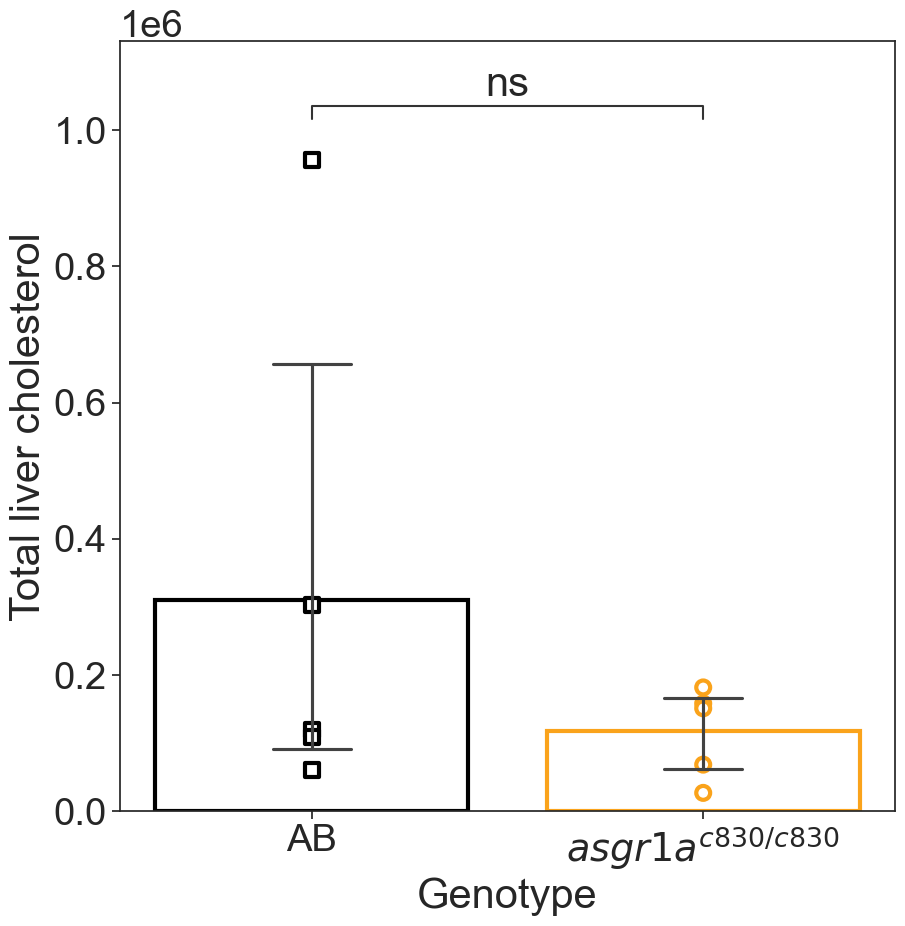

In [13]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=fig7B,x="Genotype",y="Liver CH",ax=ax,edgecolor=["Black","#FAA31B"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=fig7B,x="Genotype",hue="Genotype",y="Liver CH",palette=["Black","#FAA31B"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o"])
ax.set_ylabel("Total liver cholesterol")
for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")

pairs=[("AB","$asgr1a^{c830/c830}$")]
annotator = Annotator(ax, pairs, data=fig7B, x="Genotype", y="Liver CH")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#ax.set_ylim(0,2e6)
#plt.savefig("supp7B.svg")
plt.show()

In [14]:
absorb=pd.read_excel("Labeling_peak_climber.xlsx")
absorb["Normalized Liver Signal"]=(absorb["Liver CH"]+absorb["Liver CE"])/absorb["35 minute CAD liver"]
absorb["Normalized Intestinal Signal"]=(absorb["Intestine CE"])/absorb["35 minute CAD intestine"]
absorb["Normalized absorbed signal"]=absorb["Normalized Liver Signal"]+absorb["Normalized Intestinal Signal"]
absorb["Absorbed signal"]=absorb["Liver CH"]+absorb["Liver CE"]+absorb["Intestine CE"]
absorb["Liver signal"]=absorb["Liver CH"]+absorb["Liver CE"]

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AB vs. asgr$^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:4.178e-02 U_stat=5.100e+01


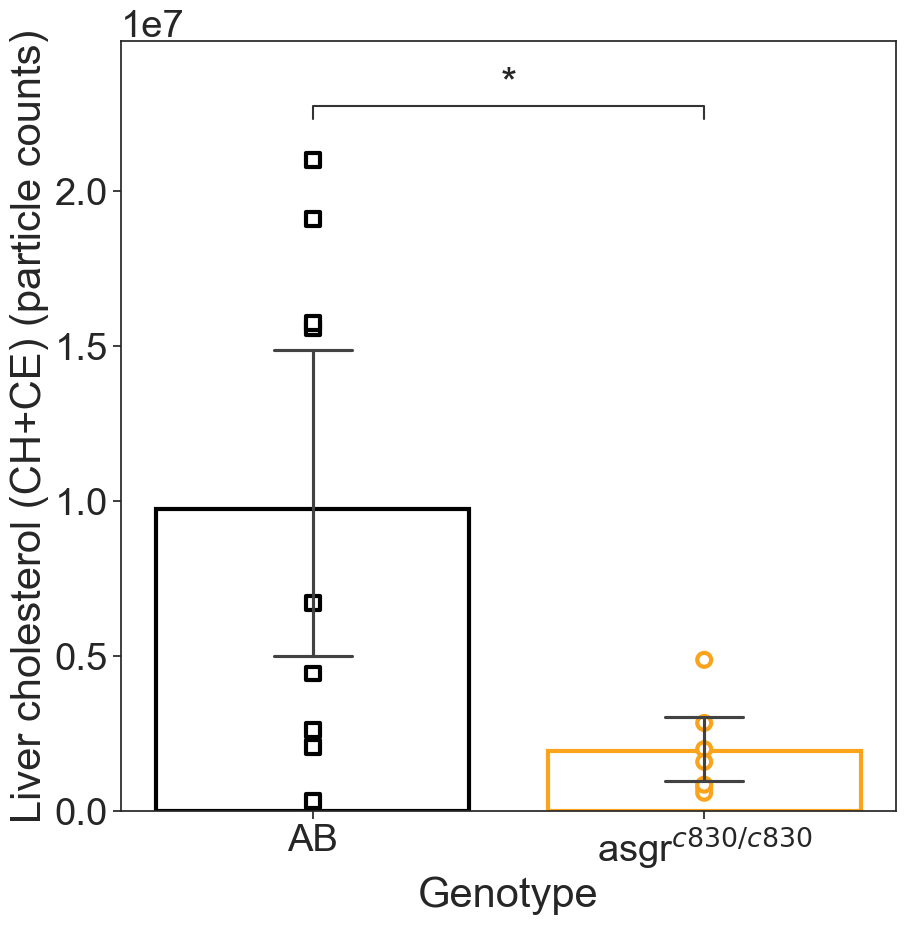

In [15]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=absorb,x="Genotype",y="Liver signal",ax=ax,edgecolor=["Black","#FAA31B"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=absorb,x="Genotype",hue="Genotype",y="Liver signal",palette=["Black","#FAA31B"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o"])
ax.set_ylabel("Liver cholesterol (CH+CE) (particle counts)")
for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")

pairs=[("AB","asgr$^{c830/c830}$")]
annotator = Annotator(ax, pairs, data=absorb, x="Genotype", y="Liver signal")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#ax.set_ylim(0,2e6)
#plt.savefig("6b.svg")
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AB vs. asgr$^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:3.510e-01 U_stat=4.100e+01


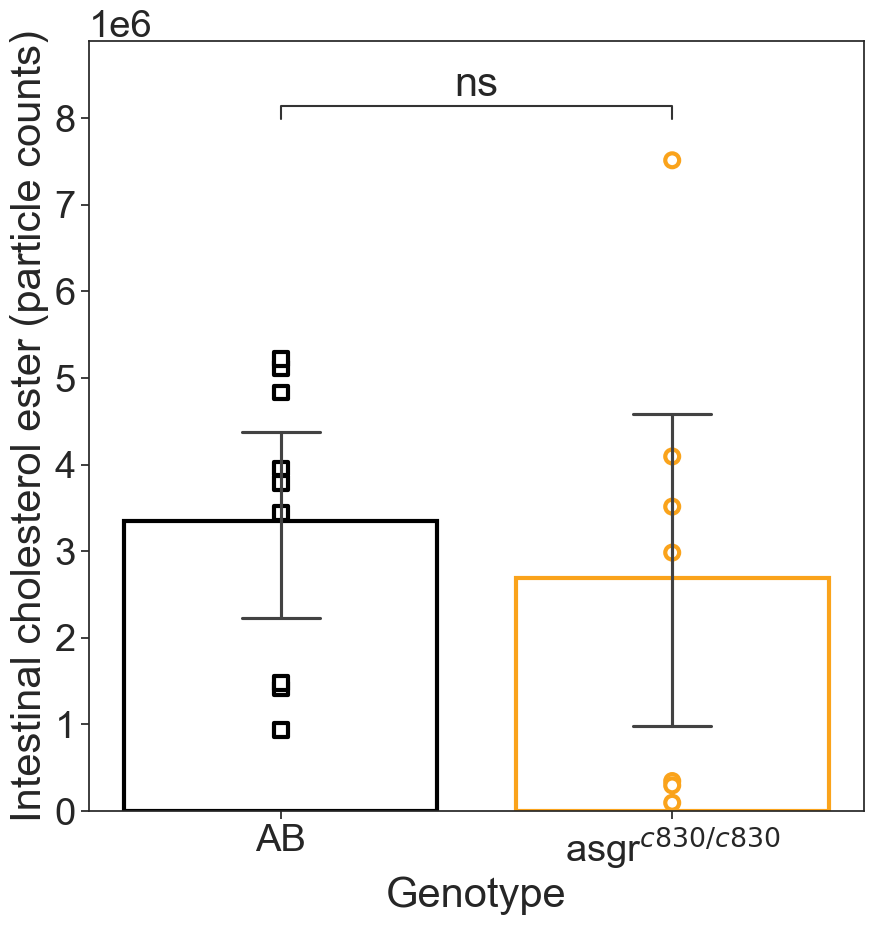

In [16]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=absorb,x="Genotype",y="Intestine CE",ax=ax,edgecolor=["Black","#FAA31B"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=absorb,x="Genotype",hue="Genotype",y="Intestine CE",palette=["Black","#FAA31B"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o"])
ax.set_ylabel("Intestinal cholesterol ester (particle counts)")
for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")

pairs=[("AB","asgr$^{c830/c830}$")]
annotator = Annotator(ax, pairs, data=absorb, x="Genotype", y="Intestine CE")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#ax.set_ylim(0,2e6)
#plt.savefig("6d.svg")
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AB vs. asgr$^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:3.112e-02 U_stat=5.200e+01


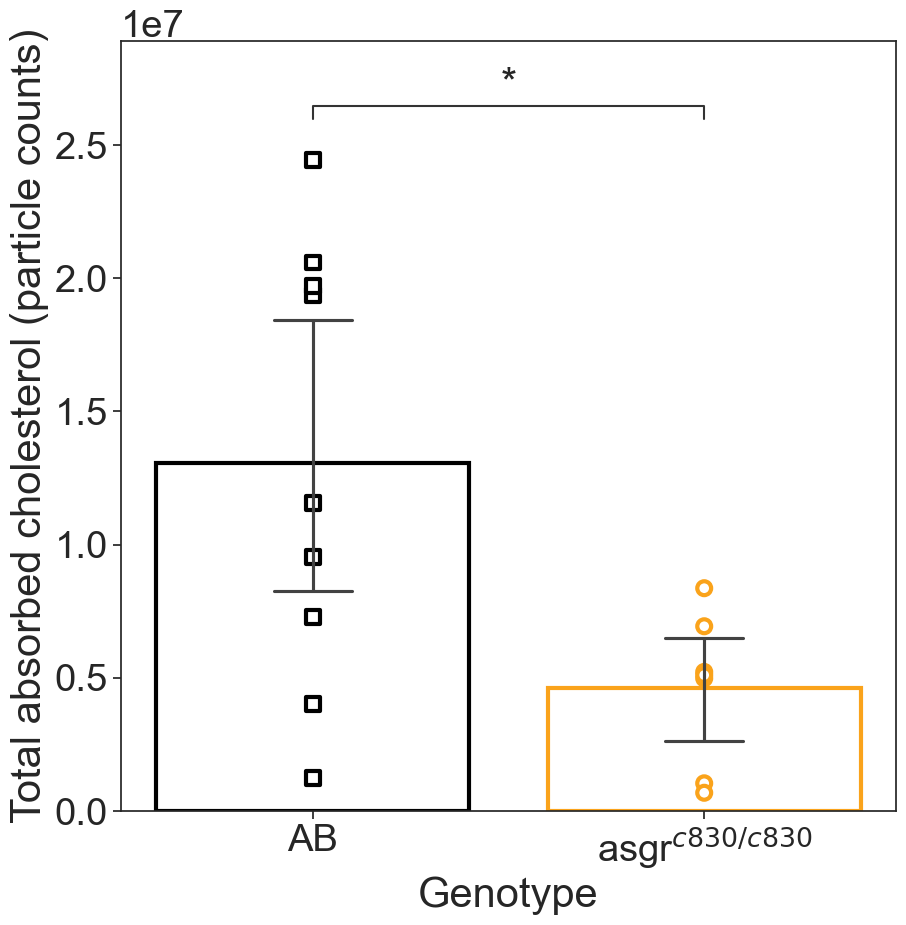

In [17]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=absorb,x="Genotype",y="Absorbed signal",ax=ax,edgecolor=["Black","#FAA31B"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=absorb,x="Genotype",hue="Genotype",y="Absorbed signal",palette=["Black","#FAA31B"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o"])
ax.set_ylabel("Total absorbed cholesterol (particle counts)")
for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")

pairs=[("AB","asgr$^{c830/c830}$")]
annotator = Annotator(ax, pairs, data=absorb, x="Genotype", y="Absorbed signal")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
#ax.set_ylim(0,2e6)
#plt.savefig("6e.svg")
plt.show()